In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# DATA UNDERSTANDING



In [7]:
df = pd.read_csv('heartV3.csv')

print("Lima data teratas:")
print(df.head())

print("\nInfo dataset:")
print(df.info())

print("\nStatistik deskriptif:")
print(df.describe())

print("\nDistribusi HeartDisease:")
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True))

Lima data teratas:
  Patient_ID  Age  Gender     ChestPain  RestingBP  Cholesterol  FastingBS  \
0       P001   63    Male  Asymptomatic        145          233          1   
1       P002   37    Male   Non-anginal        130          250          0   
2       P003   41  Female      Atypical        130          204          0   
3       P004   56    Male       Typical        120          236          0   
4       P005   57  Female  Asymptomatic        140          354          0   

   MaxHR ExerciseAngina Smoking   BMI FamilyHistory  StressLevel  \
0    150            Yes     Yes  30.1           Yes            9   
1    187             No      No  24.2            No            3   
2    172             No      No  22.8            No            4   
3    178             No     Yes  28.5           Yes            6   
4    163            Yes      No  31.2           Yes            8   

  PhysicalActivity  HeartDisease  
0           Rendah             1  
1           Tinggi             0 

In [9]:
nan_count = df['Gender'].isna().sum()
print(f"Jumlah nilai NaN pada kolom Gender: {nan_count}")

display(df[df['Gender'].isna()].head())

Jumlah nilai NaN pada kolom Gender: 0


,Patient_ID,Age,Gender,ChestPain,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Smoking,BMI,FamilyHistory,StressLevel,PhysicalActivity,HeartDisease


# DATA PREPROCESSING

In [10]:
df = pd.read_csv('heartV3.csv')

if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

if df['ExerciseAngina'].dtype == 'object':
    df['ExerciseAngina'] = df['ExerciseAngina'].map({'Yes': 1, 'No': 0})

if df['Smoking'].dtype == 'object':
    df['Smoking'] = df['Smoking'].map({'Yes': 1, 'No': 0})

if df['FamilyHistory'].dtype == 'object':
    df['FamilyHistory'] = df['FamilyHistory'].map({'Yes': 1, 'No': 0})

if 'ChestPain' in df.columns:
    df = pd.get_dummies(df, columns=['ChestPain'], drop_first=True)

activity_order = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
if df['PhysicalActivity'].dtype == 'object':
    df['PhysicalActivity'] = df['PhysicalActivity'].map(activity_order)

X = df.drop(['Patient_ID', 'HeartDisease'], axis=1)
y = df['HeartDisease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data successfully reloaded and preprocessed.")

Data successfully reloaded and preprocessed.


# Modeling

## Hyperparameter Tuning dan 10-Fold Cross Validation

### Logistic Regression

In [11]:
lr = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best parameters (Logistic Regression):", grid_lr.best_params_)
print("Best CV ROC-AUC:", grid_lr.best_score_)

Best parameters (Logistic Regression): {'C': 1, 'penalty': 'l1'}
Best CV ROC-AUC: 0.5635


### Random Forest

In [12]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best parameters (Random Forest):", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)

Best parameters (Random Forest): {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.6723333333333332


# Exploratory Data Analysis

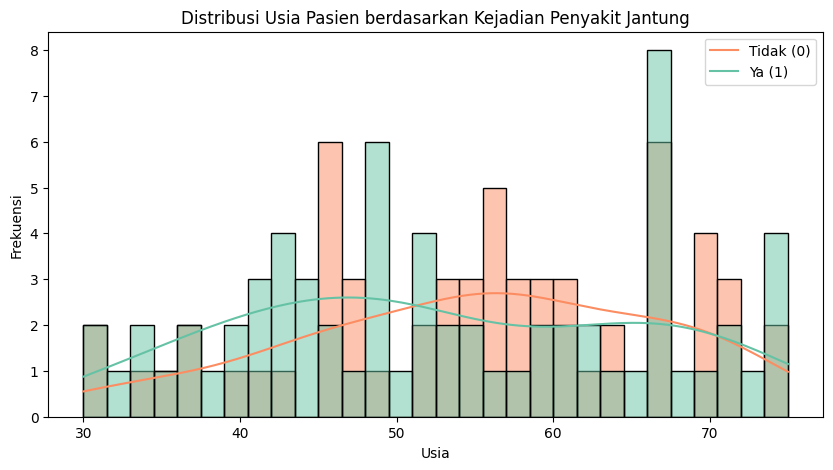

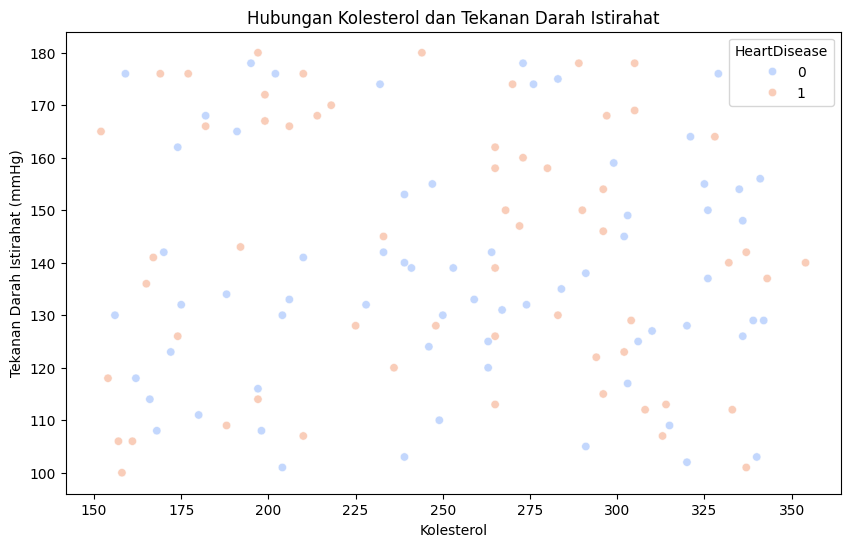

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='HeartDisease', bins=30, kde=True, palette='Set2')
plt.title('Distribusi Usia Pasien berdasarkan Kejadian Penyakit Jantung')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.legend(labels=['Tidak (0)', 'Ya (1)'])
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cholesterol', y='RestingBP', hue='HeartDisease', palette='coolwarm', alpha=0.7)
plt.title('Hubungan Kolesterol dan Tekanan Darah Istirahat')
plt.xlabel('Kolesterol')
plt.ylabel('Tekanan Darah Istirahat (mmHg)')
plt.show()

# Best Model

In [14]:
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

print("Logistic Regression CV ROC-AUC: {:.3f}".format(grid_lr.best_score_))
print("Random Forest CV ROC-AUC: {:.3f}".format(grid_rf.best_score_))

Logistic Regression CV ROC-AUC: 0.564
Random Forest CV ROC-AUC: 0.672


# Evaluasi

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       0.50      0.38      0.43        13
         Yes       0.47      0.58      0.52        12

    accuracy                           0.48        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.48      0.48      0.47        25


=== Random Forest ===
              precision    recall  f1-score   support

          No       0.79      0.85      0.81        13
         Yes       0.82      0.75      0.78        12

    accuracy                           0.80        25
   macro avg       0.80      0.80      0.80        25
weighted avg       0.80      0.80      0.80        25

ROC-AUC Logistic Regression: 0.506
ROC-AUC Random Forest: 0.897


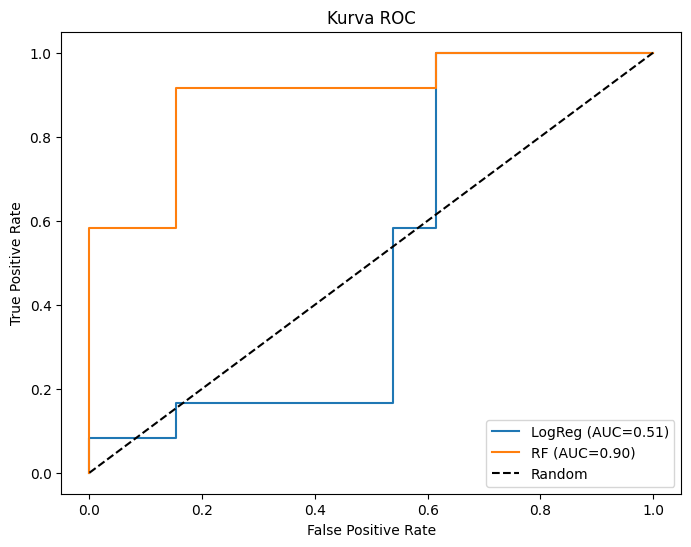

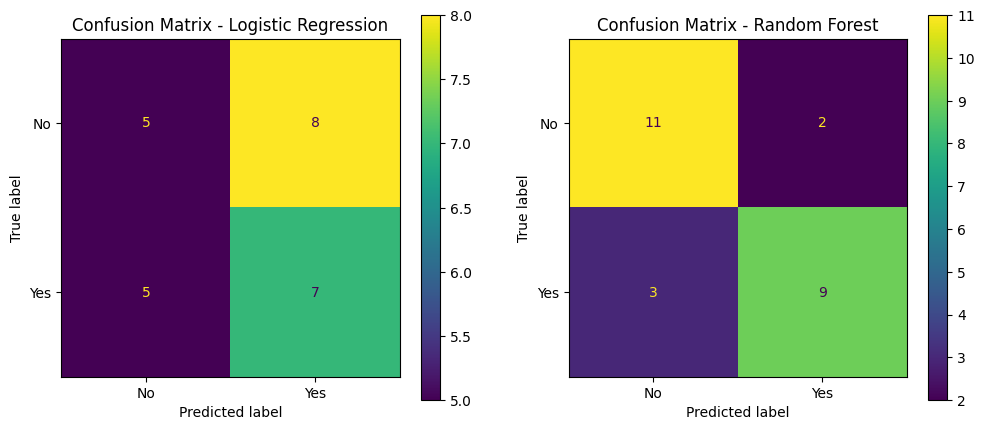

In [15]:
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:,1]

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

roc_lr = roc_auc_score(y_test, y_proba_lr)
roc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Logistic Regression: {roc_lr:.3f}")
print(f"ROC-AUC Random Forest: {roc_rf:.3f}")

plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_rf:.2f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC')
plt.legend()
plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['No','Yes'], ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No','Yes'], ax=ax[1])
ax[1].set_title('Confusion Matrix - Random Forest')
plt.show()

# Odds Ratio & Feature Importance

                  Feature  Odds Ratio
2               RestingBP    1.294536
0                     Age    1.273476
8                     BMI    1.177879
10            StressLevel    1.160867
9           FamilyHistory    1.156739
5                   MaxHR    1.000000
6          ExerciseAngina    1.000000
11       PhysicalActivity    1.000000
12     ChestPain_Atypical    1.000000
14      ChestPain_Typical    1.000000
7                 Smoking    1.000000
3             Cholesterol    0.910782
1                  Gender    0.896530
4               FastingBS    0.714560
13  ChestPain_Non-anginal    0.557768


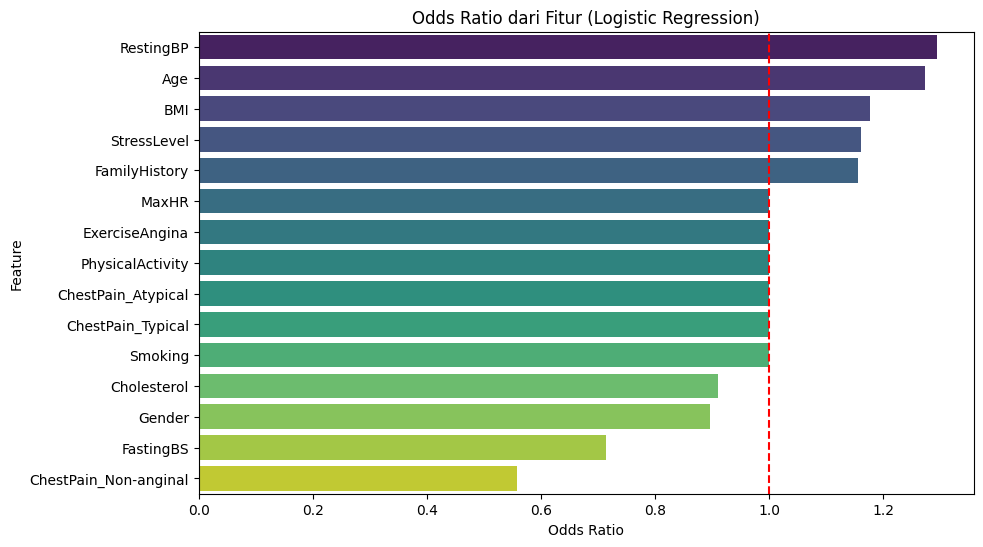

In [16]:
coef = best_lr.coef_[0]
odds_ratio = np.exp(coef)

feature_names = X.columns

or_df = pd.DataFrame({'Feature': feature_names, 'Odds Ratio': odds_ratio})
or_df = or_df.sort_values(by='Odds Ratio', ascending=False)
print(or_df)

plt.figure(figsize=(10,6))
sns.barplot(data=or_df, x='Odds Ratio', y='Feature', palette='viridis')
plt.title('Odds Ratio dari Fitur (Logistic Regression)')
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

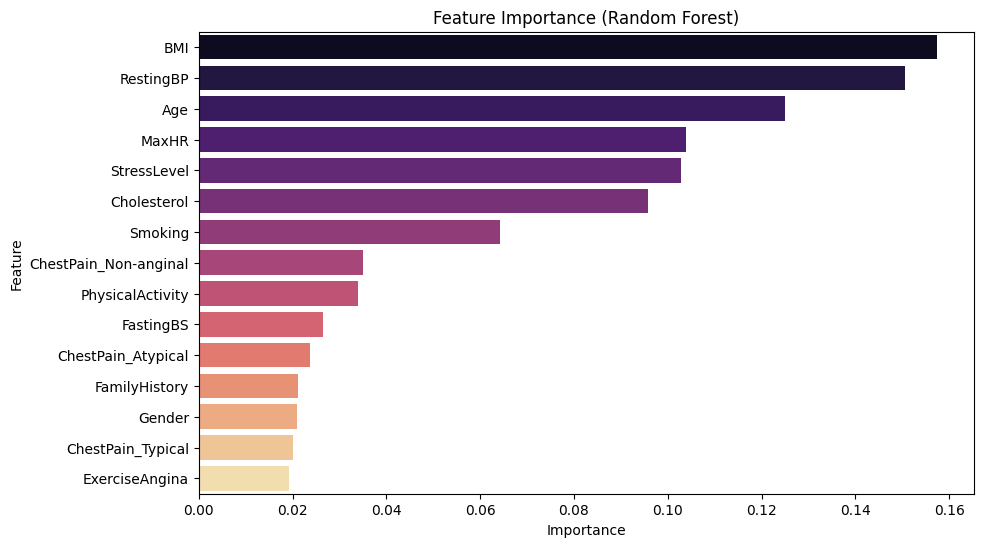

In [17]:
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.show()

# Prediksi Kasus Baru

In [22]:
new_patients_data = {
    'Age': [45, 62, 38],
    'Gender': [0, 1, 0],
    'RestingBP': [130, 160, 120],
    'Cholesterol': [220, 310, 190],
    'FastingBS': [0, 1, 0],
    'MaxHR': [162, 118, 175],
    'ExerciseAngina': [0, 1, 0],
    'Smoking': [0, 1, 0],
    'BMI': [25.0, 33.5, 22.0],
    'FamilyHistory': [0, 1, 0],
    'StressLevel': [3, 9, 2],
    'PhysicalActivity': [2, 0, 2],
    'ChestPain_Atypical': [0,0,0],
    'ChestPain_Non-anginal': [0,0,0],
    'ChestPain_Typical': [0,0,0]
}

new_patients = pd.DataFrame(new_patients_data)
new_patients = new_patients.reindex(columns=feature_names, fill_value=0)
new_patients_scaled = scaler.transform(new_patients)

prediksi = best_rf.predict(new_patients_scaled)
probabilitas = best_rf.predict_proba(new_patients_scaled)[:,1]

hasil = pd.DataFrame({
    'Pasien_Ke': range(1, len(new_patients)+1),
    'Prediksi': ['Ya' if p==1 else 'Tidak' for p in prediksi],
    'Probabilitas_Positif': probabilitas
})
print(hasil)

   Pasien_Ke Prediksi  Probabilitas_Positif
0          1    Tidak              0.359540
1          2       Ya              0.754749
2          3    Tidak              0.388998


# UI V3

In [ ]:
import pickle

pickle.dump(best_rf, open("model_rfV2.pkl", "wb"))
pickle.dump(scaler, open("scalerV2.pkl", "wb"))
pickle.dump(list(feature_names), open("feature_namesV2.pkl", "wb"))

In [60]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

model = joblib.load(open('model_rf.pkl', 'rb'))
scaler = joblib.load(open('scaler.pkl', 'rb'))
feature_names = joblib.load(open('feature_names.pkl', 'rb'))

st.title("Prediksi Penyakit Jantung ❤️")
st.write("Masukkan data pasien untuk memprediksi risiko penyakit jantung")

age = st.number_input("Age", 1, 120, 30)
gender = st.selectbox("Gender", ["Female", "Male"])
resting_bp = st.number_input("Resting BP", 80, 200, 120)
chol = st.number_input("Cholesterol", 100, 400, 200)
fbs = st.selectbox("Fasting Blood Sugar > 120?", ["No", "Yes"])
max_hr = st.number_input("Max Heart Rate", 60, 220, 150)
angina = st.selectbox("Exercise Angina", ["No", "Yes"])
smoking = st.selectbox("Smoking", ["No", "Yes"])
bmi = st.number_input("BMI", 10.0, 50.0, 25.0)
family = st.selectbox("Family History", ["No", "Yes"])
stress = st.slider("Stress Level", 1, 10, 5)
activity = st.selectbox("Physical Activity", ["Rendah", "Sedang", "Tinggi"])
chestpain = st.selectbox("Chest Pain Type", ["Typical", "Atypical", "Non-anginal", "Asymptomatic"])

gender = 1 if gender == "Male" else 0
fbs = 1 if fbs == "Yes" else 0
angina = 1 if angina == "Yes" else 0
smoking = 1 if smoking == "Yes" else 0
family = 1 if family == "Yes" else 0

activity_map = {"Rendah":0, "Sedang":1, "Tinggi":2}
activity = activity_map[activity]

cp_typical = 1 if chestpain == "Typical" else 0
cp_atypical = 1 if chestpain == "Atypical" else 0
cp_non = 1 if chestpain == "Non-anginal" else 0

# Data input
input_data = {
    'Age': age,
    'Gender': gender,
    'RestingBP': resting_bp,
    'Cholesterol': chol,
    'FastingBS': fbs,
    'MaxHR': max_hr,
    'ExerciseAngina': angina,
    'Smoking': smoking,
    'BMI': bmi,
    'FamilyHistory': family,
    'StressLevel': stress,
    'PhysicalActivity': activity,
    'ChestPain_Atypical': cp_atypical,
    'ChestPain_Non-anginal': cp_non,
    'ChestPain_Typical': cp_typical
}

input_df = pd.DataFrame([input_data])
input_df = input_df.reindex(columns=feature_names, fill_value=0)
input_scaled = scaler.transform(input_df)

if st.button("Prediksi"):
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]

    if pred == 1:
        st.error(f"Berisiko Penyakit Jantung ❗ (Prob: {prob:.2f})")
    else:
        st.success(f"Tidak Berisiko ✅ (Prob: {prob:.2f})")

Overwriting app.py


In [69]:
!pkill -f streamlit

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

In [70]:
import os

os.system("streamlit run app.py --server.port 8501 &")

!./cloudflared-linux-amd64 tunnel --url http://localhost:8501

2026-05-11T07:35:52Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-11T07:35:52Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-11T07:35:57Z INF +--------------------------------------------------------------------------------------------+
2026-05-11T07:35:57Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-11T07:35:57Z INF |  https://agency-hampton-spring-creator.trycloudflare.c